In [5]:
from pathlib import Path

# 1. Point to your main folders
train_path = Path("DataSet/Sample_Training")
test_path = Path("DataSet/Sample_Test")

# 2. Use rglob to recursively find all .csv files
train_csv_files = list(train_path.rglob("*.csv"))
test_csv_files = list(test_path.rglob("*.csv"))

# 3. Print the results
print(f"Total CSV files in Training: {len(train_csv_files)}")
print(f"Total CSV files in Test: {len(test_csv_files)}")
print(f"Total Dataset CSVs: {len(train_csv_files) + len(test_csv_files)}")

Total CSV files in Training: 2473
Total CSV files in Test: 586
Total Dataset CSVs: 3059


In [6]:
import pandas as pd
from pathlib import Path

# 1. Point to your training folder
train_path = Path("DataSet/Sample_Training")
train_csv_files = list(train_path.rglob("*.csv"))

# Counters
single_label_files = 0
only_zeros = 0
only_ones = 0

print(f"Scanning {len(train_csv_files)} training files... This might take a few seconds.\n")

for file_path in train_csv_files:
    # Read the file
    df = pd.read_csv(file_path)
    
    # Grab the very last column (the label)
    labels = df.iloc[:, -1]
    
    # Check how many unique values exist in that column
    unique_classes = labels.unique()
    
    # If there is only 1 unique value, the file has only one label
    if len(unique_classes) == 1:
        single_label_files += 1
        
        # Check which label it is
        if unique_classes[0] == 0:
            only_zeros += 1
        elif unique_classes[0] == 1:
            only_ones += 1

# Print the results
print("=== File Label Analysis ===")
print(f"Total files with only ONE label: {single_label_files}")
print(f"  ↳ Files containing strictly 0s: {only_zeros}")
print(f"  ↳ Files containing strictly 1s: {only_ones}")
print(f"\nFiles containing BOTH 0s and 1s: {len(train_csv_files) - single_label_files}")

Scanning 2473 training files... This might take a few seconds.

=== File Label Analysis ===
Total files with only ONE label: 611
  ↳ Files containing strictly 0s: 611
  ↳ Files containing strictly 1s: 0

Files containing BOTH 0s and 1s: 1862


Creating a Dataframe that has all the entries of sample training

In [7]:
import pandas as pd
from pathlib import Path

# 1. Define the path to the training folder
train_path = Path("DataSet/Sample_Training")

# Find all CSV files recursively
train_csv_files = list(train_path.rglob("*.csv"))

all_data = []

print(f"Combining {len(train_csv_files)} files... This might take a moment.")

# 2. Loop through, read, and tag each file
for file_path in train_csv_files:
    # Read the CSV
    df = pd.read_csv(file_path)
    
    # ⚠️ CRITICAL: Tag the data with its source file name (e.g., 'File_123')
    # file_path.stem grabs just the file name without the '.csv' part
    df['Recording_ID'] = file_path.stem 
    
    # Append the tagged dataframe to our master list
    all_data.append(df)

# 3. Concatenate everything into one master DataFrame
# ignore_index=True ensures our row numbers go smoothly from 0 to 1.2 million
df_train_full = pd.concat(all_data, ignore_index=True)

# 4. Display the results
print("\n=== Combination Complete ===")
print(f"Total Rows: {df_train_full.shape[0]:,}")  # The :, adds commas for readability
print(f"Total Columns: {df_train_full.shape[1]}")
print(f"Number of Unique Recordings: {df_train_full['Recording_ID'].nunique()}")

print("\nFirst 5 Rows:")
display(df_train_full.head())

Combining 2473 files... This might take a moment.

=== Combination Complete ===
Total Rows: 1,233,209
Total Columns: 13
Number of Unique Recordings: 2473

First 5 Rows:


,TimeStamp(s),FrameCounter,AccX,AccY,AccZ,GyrX,GyrY,GyrZ,EulerX,EulerY,EulerZ,FallCheck,Recording_ID
0,0.01,1,-0.030002,-1.009000,0.076000,0.000277,0.802011,0.401101,94.308877,-1.220404,-35.236922,0,S11T03R05
1,0.02,2,-0.032211,-1.009808,0.075337,-0.319363,0.984640,0.496969,94.277099,-1.236896,-35.231083,0,S11T03R05
2,0.03,3,-0.034100,-1.010341,0.074613,-0.587184,1.161781,0.536548,94.249658,-1.252811,-35.222478,0,S11T03R05
3,0.04,4,-0.035516,-1.010077,0.073824,-0.786074,1.297451,0.491289,94.231454,-1.265816,-35.210950,0,S11T03R05
4,0.05,5,-0.036178,-1.008464,0.072956,-0.927520,1.357008,0.371348,94.220391,-1.273771,-35.198129,0,S11T03R05


Visualizing the data


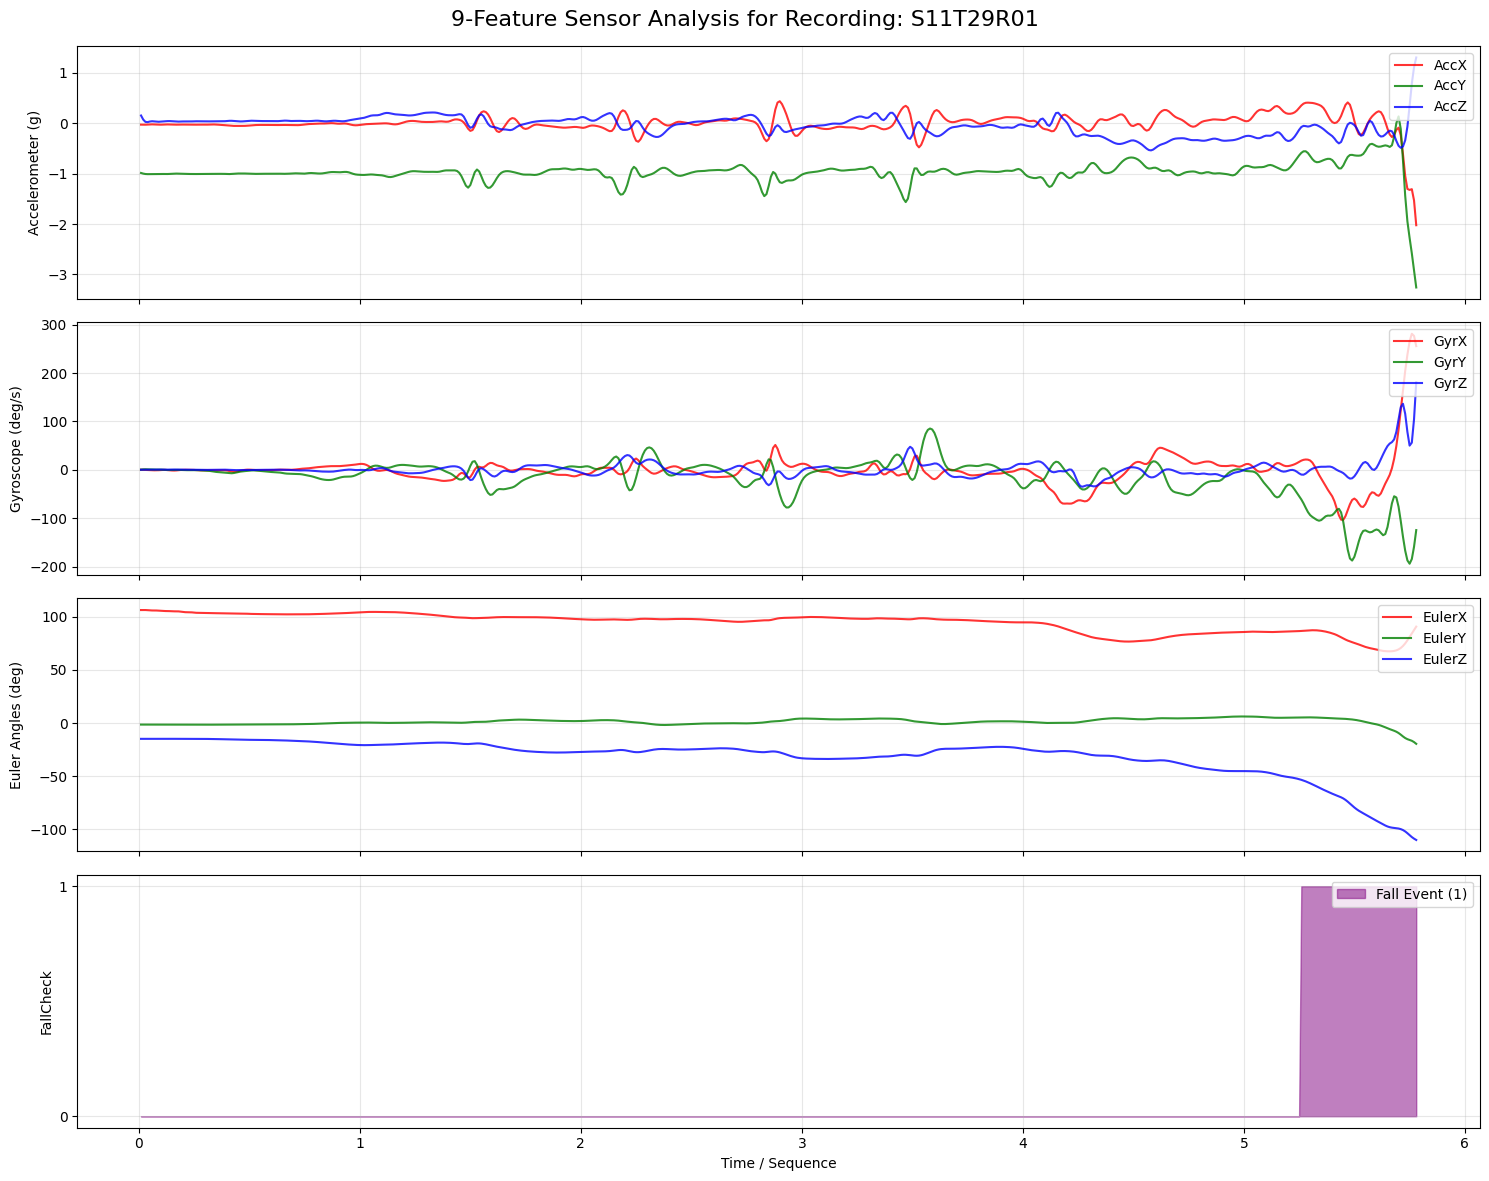

creating windows and labelling them  


Assumption: Ensure we never create corrupted windows that cross over from one file to the next.

In [16]:
import numpy as np
import pandas as pd

def create_windows_safely(df_full, window_len=50, overlap_ratio=0.5, threshold=0.4):
    print("Extracting 3D windows file-by-file...")
    
    # Calculate step size (25) and threshold for ones (20)
    step = int(window_len * (1 - overlap_ratio))
    ones_threshold = window_len * threshold  

    # Define our exact features based on the dataset rules
    # We deliberately exclude TimeStamp and FrameCounter
    feature_cols = ['AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ', 'EulerX', 'EulerY', 'EulerZ']
    label_col = 'FallCheck'

    all_X = []
    all_y = []

    # Group by the Recording_ID we created to prevent cross-file contamination
    for recording_id, group_df in df_full.groupby('Recording_ID'):
        
        # Convert to pure NumPy arrays for blazing fast slicing
        feats = group_df[feature_cols].values
        labels = group_df[label_col].values
        
        # Slide the window across this single recording
        for start in range(0, len(group_df) - window_len + 1, step):
            
            # Slice the 50 rows for both features and labels
            window_X = feats[start : start + window_len]
            window_y = labels[start : start + window_len]
            
            # Apply the 40% rule for labeling the entire window
            if np.sum(window_y == 1) > ones_threshold:
                win_label = 1
            else:
                win_label = 0
                
            all_X.append(window_X)
            all_y.append(win_label)

    # Convert lists into final 3D and 1D NumPy arrays
    X_final = np.array(all_X)
    y_final = np.array(all_y)
    
    return X_final, y_final

# Execute the function on your master dataframe
X_full, y_full = create_windows_safely(df_train_full)

print("\n--- Window Extraction Complete ---")
print(f"Features Array Shape (X_full): {X_full.shape}")
print(f"Target Array Shape (y_full): {y_full.shape}")
print(f"Class Balance: {pd.Series(y_full).value_counts().to_dict()}")

Extracting 3D windows file-by-file...

--- Window Extraction Complete ---
Features Array Shape (X_full): (45664, 50, 9)
Target Array Shape (y_full): (45664,)
Class Balance: {0: 41632, 1: 4032}


In [17]:
df_train_full.describe()

,TimeStamp(s),FrameCounter,AccX,AccY,AccZ,GyrX,GyrY,GyrZ,EulerX,EulerY,EulerZ,FallCheck
count,1.233209e+06,1.233209e+06,1.233209e+06,1.233209e+06,1.233209e+06,1.233209e+06,1.233209e+06,1.233209e+06,1.233209e+06,1.233209e+06,1.233209e+06,1.233209e+06
mean,3.038358e+00,3.038358e+02,-1.777964e-03,-9.166943e-01,-7.513311e-02,-5.272566e+00,8.178480e+00,-7.790603e-01,8.151976e+01,-3.289738e-01,-1.485204e+01,1.114118e-01
std,2.428863e+00,2.428863e+02,2.406490e-01,3.555180e-01,3.565363e-01,4.163168e+01,4.725563e+01,2.081291e+01,2.095539e+01,7.085386e+00,5.826432e+01,3.146415e-01
min,1.000000e-02,1.000000e+00,-4.246039e+00,-4.324529e+00,-4.306751e+00,-9.469908e+02,-6.930906e+02,-5.948486e+02,-2.151386e+02,-8.927872e+01,-2.390315e+02,0.000000e+00
25%,1.250000e+00,1.250000e+02,-6.192531e-02,-1.010017e+00,-1.620754e-01,-1.070843e+01,-5.372488e+00,-4.380489e+00,7.886315e+01,-2.703164e+00,-4.323459e+01,0.000000e+00
50%,2.520000e+00,2.520000e+02,-1.056054e-02,-9.880230e-01,-6.532253e-03,-6.304042e-01,2.933085e-01,-5.347000e-02,8.680001e+01,-6.358144e-01,-2.370269e+01,0.000000e+00
75%,4.050000e+00,4.050000e+02,4.711053e-02,-8.729966e-01,9.893927e-02,4.869977e+00,1.278237e+01,3.425534e+00,9.251868e+01,1.445319e+00,-8.590804e+00,0.000000e+00
max,1.488000e+01,1.488000e+03,4.286366e+00,4.129235e+00,4.413994e+00,1.670007e+03,6.758569e+02,4.516763e+02,2.179554e+02,8.906624e+01,2.399907e+02,1.000000e+00


Scaling the data

In [19]:
from sklearn.model_selection import train_test_split
X_train, y_train, X_test, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
print(f"Training set shapes: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Testing set shapes: X_test: {X_test.shape}, y_test: {y_test.shape}")

Training set shapes: X_train: (36531, 50, 9), y_train: (9133, 50, 9)
Testing set shapes: X_test: (36531,), y_test: (9133,)


In [23]:
from sklearn.preprocessing import StandardScaler

def scale_3d_folds(X_train_3d,X_val_3d):
    num_train_windows=X_train_3d.shape[0]
    num_val_windows=X_val_3d.shape[0]
    time_steps=X_train_3d.shape[1]
    num_features=X_train_3d.shape[2]

    scaler=StandardScaler()

    # Reshape to 2D for scaling
    X_train_2d=X_train_3d.reshape(-1,num_features)
    X_val_2d=X_val_3d.reshape(-1,num_features)

    # Fit the scaler on training data and transform both training and validation data
    X_train_2d_scaled=scaler.fit_transform(X_train_2d)
    X_val_2d_scaled=scaler.transform(X_val_2d)

    # Reshape back to 3D
    X_train_3d_scaled=X_train_2d_scaled.reshape(num_train_windows,time_steps,num_features)
    X_val_3d_scaled=X_val_2d_scaled.reshape(num_val_windows,time_steps,num_features)

    return X_train_3d_scaled, X_val_3d_scaled

Testing GPU status

In [26]:
import torch

# Check if CUDA is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU


In [27]:
from torch.utils.data import Dataset, DataLoader

class IMUDataset(Dataset):
    def __init__(self, X_data, y_data):
        """
        X_data: NumPy array of shape (N, 50, 9)
        y_data: NumPy array of shape (N,)
        """
        self.X = X_data
        self.y = y_data

    def __len__(self):
        # Returns the total number of windows
        return len(self.y)

    def __getitem__(self, idx):
        # 1. Grab the single window and label at this index
        window = self.X[idx] # Shape is currently (50, 9)
        label = self.y[idx]
        
        # --- CHALLENGE 1: The Shape Flip ---
        # Transpose the window from (50, 9) to (9, 50)
        window_transposed = window.T  # Now shape is (9, 50) 
        
        # --- CHALLENGE 2: The Tensor Conversion ---
        # Convert the transposed numpy array to a PyTorch 32-bit float tensor
        # Convert the label to a PyTorch 32-bit float tensor (needed for binary cross entropy)
        x_tensor = torch.tensor(window_transposed, dtype=torch.float32)
        y_tensor = torch.tensor(label, dtype=torch.float32)
        
        return x_tensor, y_tensor

In [28]:
import torch.nn as nn
import torch.nn.functional as F

class FallDetector1DCNN_PT(nn.Module):
    def __init__(self):
        super(FallDetector1DCNN_PT, self).__init__()
        
        # --- Feature Extraction Block 1 ---
        # The data arrives here shaped as (Batch, 9, 50)
        # CHALLENGE 1: How many channels are coming into this first layer?
        self.conv1 = nn.Conv1d(in_channels=9, out_channels=64, kernel_size=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        # --- Feature Extraction Block 2 ---
        # 64 channels come out of the first block, so 64 go into this one
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3)
        self.bn2 = nn.BatchNorm1d(128)
        
        # Global Average Pooling flattens the sequence length to 1
        # This converts our (Batch, 128, sequence_length) to (Batch, 128, 1)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # --- Classification Block ---
        # CHALLENGE 2: After pooling and flattening, how many features are entering this Dense layer?
        self.fc1 = nn.Linear(in_features=128, out_features=64)
        self.dropout = nn.Dropout(0.5)
        
        # Final output (Notice: No sigmoid here! Just a raw linear layer)
        self.fc2 = nn.Linear(in_features=64, out_features=1)

    def forward(self, x):
        # Pass through Block 1
        x = self.conv1(x)
        x = F.relu(self.bn1(x))
        x = self.pool1(x)
        
        # Pass through Block 2
        x = self.conv2(x)
        x = F.relu(self.bn2(x))
        x = self.global_pool(x)
        
        # Flatten the (Batch, 128, 1) tensor to (Batch, 128)
        x = torch.flatten(x, 1)
        
        # Pass through Classification Block
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x) # Raw logit output
        
        # Squeeze the output from (Batch, 1) to (Batch,) to match our target labels
        return x.squeeze(1)

# Instantiate the model and send it to the RTX 3050!
model = FallDetector1DCNN_PT().to(device)

In [29]:
from sklearn.model_selection import train_test_split

# 1. Split the raw 3D data first
print("Splitting data...")
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_full , 
    y_full, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_full
)

# 2. Call our custom modular function to handle the 3D scaling safely!
print("Scaling data using scale_3d_folds()...")
X_train_scaled, X_val_scaled = scale_3d_folds(X_train_raw, X_val_raw)

# 3. Wrap them in the PyTorch Dataset class
print("Creating PyTorch Datasets...")
train_dataset = IMUDataset(X_train_scaled, y_train)
val_dataset = IMUDataset(X_val_scaled, y_val)

print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Val Dataset Size:   {len(val_dataset)}")

Splitting data...
Scaling data using scale_3d_folds()...
Creating PyTorch Datasets...
Train Dataset Size: 36531
Val Dataset Size:   9133


In [31]:
from torch.utils.data import DataLoader
import torch.optim as optim

# 1. Create DataLoaders (This handles the batching automatically!)
# We shuffle the training data, but NEVER the validation data
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# 2. Calculate pos_weight for the highly imbalanced falls
# (Assuming y_train is your numpy array of labels)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
imbalance_ratio = torch.tensor([neg_count / pos_count], dtype=torch.float32).to(device)

# 3. Initialize Model, Loss, and Optimizer
model = FallDetector1DCNN_PT().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=imbalance_ratio)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. The Training Epoch Loop
epochs = 30

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() # Tell the model it's training time (turns ON Dropout and BatchNorm)
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Move data to the RTX 3050
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # --- THE CHALLENGE: The Holy Trinity ---
        
        # Step 1: Clear the old gradients
        optimizer.zero_grad()
        
        # Forward pass: push data through the model
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # Step 2: Backpropagation (calculate the new gradients)
        loss.backward()
        
        # Step 3: Update the weights
        optimizer.step()
        
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    
    # --- VALIDATION PHASE ---
    model.eval() # Tell the model it's evaluation time (turns OFF Dropout)
    val_loss = 0.0
    
    # We use torch.no_grad() because we don't need to calculate gradients for validation
    # This saves a massive amount of GPU memory and time
    with torch.no_grad():
        for val_X, val_y in val_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            val_preds = model(val_X)
            v_loss = criterion(val_preds, val_y)
            val_loss += v_loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch [1/30] | Train Loss: 0.3702 | Val Loss: 0.2771
Epoch [2/30] | Train Loss: 0.2499 | Val Loss: 0.2140
Epoch [3/30] | Train Loss: 0.2220 | Val Loss: 0.2064
Epoch [4/30] | Train Loss: 0.2052 | Val Loss: 0.2202
Epoch [5/30] | Train Loss: 0.1923 | Val Loss: 0.1999
Epoch [6/30] | Train Loss: 0.1839 | Val Loss: 0.1818
Epoch [7/30] | Train Loss: 0.1817 | Val Loss: 0.1752
Epoch [8/30] | Train Loss: 0.1789 | Val Loss: 0.1930
Epoch [9/30] | Train Loss: 0.1741 | Val Loss: 0.1917
Epoch [10/30] | Train Loss: 0.1660 | Val Loss: 0.1933
Epoch [11/30] | Train Loss: 0.1627 | Val Loss: 0.1736
Epoch [12/30] | Train Loss: 0.1592 | Val Loss: 0.1691
Epoch [13/30] | Train Loss: 0.1534 | Val Loss: 0.1609
Epoch [14/30] | Train Loss: 0.1568 | Val Loss: 0.1773
Epoch [15/30] | Train Loss: 0.1473 | Val Loss: 0.1497
Epoch [16/30] | Train Loss: 0.1530 | Val Loss: 0.1581
Epoch [17/30] | Train Loss: 0.1471 | Val Loss: 0.1794
Epoch [18/30] | Train Loss: 0.1389 | Val Loss: 0.1623
Epoch [19/30] | Train Loss: 0.1464 | 


--- Validation Classification Report ---
              precision    recall  f1-score   support

  Normal (0)       1.00      0.96      0.98      8327
    Fall (1)       0.70      0.97      0.82       806

    accuracy                           0.96      9133
   macro avg       0.85      0.96      0.90      9133
weighted avg       0.97      0.96      0.96      9133



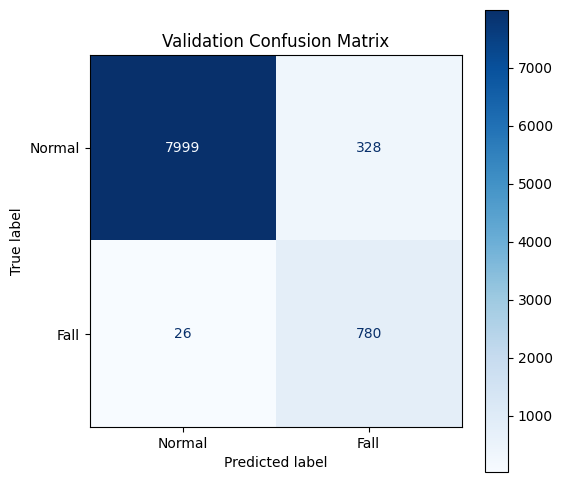

In [32]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Put the model in evaluation mode
model.eval()

all_preds = []
all_targets = []

# 2. Run the Validation Loader one more time
with torch.no_grad():
    for val_X, val_y in val_loader:
        # Move data to GPU
        val_X = val_X.to(device)
        
        # Get the raw output (logits) from the model
        logits = model(val_X)
        
        # CRITICAL: We used BCEWithLogitsLoss, so the output doesn't have a Sigmoid yet.
        # We must apply it manually now to get probabilities between 0.0 and 1.0
        probs = torch.sigmoid(logits)
        
        # Threshold at 0.5 to convert probabilities into absolute 0s and 1s
        preds = (probs > 0.5).float()
        
        # Move the tensors back to the CPU and convert to NumPy lists
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(val_y.numpy()) # val_y is already on CPU from the loader

# Convert lists to NumPy arrays
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# 3. Print the Classification Report
print("\n--- Validation Classification Report ---")
print(classification_report(all_targets, all_preds, target_names=['Normal (0)', 'Fall (1)']))

# 4. Plot the Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fall'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Validation Confusion Matrix')
plt.show()

In [1]:
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
import numpy as np
import warnings

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"=== Initializing Bayesian Optimization Engine on {device} ===")

# ==========================================
# 1. The Dynamic Architecture
# ==========================================
class DynamicFallDetector(nn.Module):
    def __init__(self, num_filters, dropout_rate):
        super(DynamicFallDetector, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=9, out_channels=num_filters, kernel_size=3)
        self.bn1 = nn.BatchNorm1d(num_filters)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=num_filters, out_channels=num_filters*2, kernel_size=3)
        self.bn2 = nn.BatchNorm1d(num_filters*2)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        self.fc1 = nn.Linear(in_features=num_filters*2, out_features=64)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(in_features=64, out_features=1)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.global_pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x).squeeze(1)

class FallDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx].T, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.float32)

# Calculate the imbalanced pos_weight penalty ONCE
num_zeros = np.sum(y_train == 0)
num_ones = np.sum(y_train == 1)
pos_weight_tensor = torch.tensor([num_zeros / num_ones], dtype=torch.float32).to(device)

# ==========================================
# 2. The Optuna Objective Function
# ==========================================
def objective(trial):
    # Let Optuna smartly suggest parameters from these distributions
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout_rate = trial.suggest_float("dropout_rate", 0.3, 0.7)
    num_filters = trial.suggest_categorical("num_filters", [32, 64, 128])
    
    # Build dynamic loaders and model
    train_loader = DataLoader(FallDataset(X_train_scaled, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(FallDataset(X_val_scaled, y_val), batch_size=batch_size, shuffle=False)
    
    model = DynamicFallDetector(num_filters=num_filters, dropout_rate=dropout_rate).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # We only train for 8 epochs per trial to save time. 
    # If a combo is good, it will show high F1 by epoch 8.
    EPOCHS = 8 
    
    for epoch in range(EPOCHS):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            
    # Evaluate strictly on F1-Score
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for val_X, val_y in val_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            val_logits = model(val_X)
            preds = (torch.sigmoid(val_logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(val_y.cpu().numpy())
            
    # Optuna will try to MAXIMIZE this exact return value
    return f1_score(all_targets, all_preds)

# ==========================================
# 3. Execute the Bayesian Search
# ==========================================
print("\n--- Commencing Optuna TPE Search ---")
# direction="maximize" because we want the highest F1 possible
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())

# Run 20 different intelligent guesses
study.optimize(objective, n_trials=20)

print("\n" + "="*50)
print("             BAYESIAN SEARCH COMPLETE")
print("="*50)
print(f"Absolute Best Validation F1: {study.best_value:.4f}")
print("Winning Hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f" - {key}: {value}")

/mnt/s/backup/DM_PROJECT/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 